In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

# Mutual information

In [2]:
# Load dataset
df = pd.read_excel('Cleaned_Dataset 2.xlsx')

# Melihat dimensi data
print(f"Dimensi data: {df.shape}")

# Melihat beberapa baris pertama data
display(df.head())

Dimensi data: (549, 13)


,SO2 (mg/nm3),Nox (mg/nm3),CO (mg/nm3),CO2 (ppm),O2 (%),Velocity (m/s),Temp. (°C),Pressure (Kpa),Flow rate (KNm3/h),Opacity (%),Dust (mg/nm3),Boiler Eff (%),NPHR (Kcal/Kwh)
0,467.109710,215.343399,675.494230,104149.435825,5.733319,13.543683,103.555908,-0.268340,521.201534,49.690183,0.269452,77.915748,2607.270106
1,487.997713,186.102138,677.919792,106112.301201,5.007743,12.093034,99.353094,-0.254642,465.376223,49.691542,0.270812,76.294873,2687.121676
2,498.073246,188.988139,679.644721,106005.810713,4.783563,11.900385,95.308560,-0.248897,457.962513,49.697809,0.272701,77.886219,2663.032090
3,503.058633,194.010835,682.033313,104089.430589,4.842330,11.613680,87.355418,-0.225933,446.929254,49.702891,0.274674,78.367624,2651.943177
4,450.895453,132.718747,478.544209,98360.057466,5.686940,12.103985,89.364968,-0.235743,465.797638,49.688853,0.283205,77.856369,2651.524408


In [3]:
# Definisikan target dan fitur
target_columns = ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']

# Pastikan target columns ada dalam dataset
for target in target_columns:
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' tidak ditemukan dalam dataset")

# Pisahkan fitur dan target
X = df.drop(target_columns, axis=1)
y_boiler_eff = df['Boiler Eff (%)']
y_nphr = df['NPHR (Kcal/Kwh)']

print(f"Jumlah fitur: {X.shape[1]}")
print(f"Jumlah sampel: {X.shape[0]}")

Jumlah fitur: 11
Jumlah sampel: 549


In [4]:
# Cek apakah ada nilai yang hilang
print("\nJumlah nilai yang hilang di setiap fitur:")
print(X.isnull().sum().sort_values(ascending=False).head(10))  # Tampilkan 10 teratas



Jumlah nilai yang hilang di setiap fitur:
SO2 (mg/nm3)          0
Nox (mg/nm3)          0
CO (mg/nm3)           0
CO2 (ppm)             0
O2 (%)                0
Velocity (m/s)        0
Temp. (°C)            0
Pressure (Kpa)        0
Flow rate (KNm3/h)    0
Opacity (%)           0
dtype: int64


In [5]:
# Cek tipe data fitur
print("\nTipe data fitur:")
print(X.dtypes.value_counts())


Tipe data fitur:
float64    11
Name: count, dtype: int64


In [6]:
# Hapus kolom non-numerik jika ada (untuk mutual information)
non_numeric_cols = X.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric_cols:
    print(f"\nMenghapus kolom non-numerik: {non_numeric_cols}")
    X = X.select_dtypes(include=['number'])

In [7]:
# Feature Selection dengan Mutual Information untuk target 1: Boiler Eff (%)
print("\n=== Feature Selection untuk Boiler Eff (%) ===")


=== Feature Selection untuk Boiler Eff (%) ===


In [8]:
# Hitung skor Mutual Information
# Mutual Information mengukur seberapa banyak informasi yang diberikan sebuah fitur tentang target
# Formula dasar: MI(X; Y) = H(Y) - H(Y|X)
# di mana:
#   H(Y) = entropy target
#   H(Y|X) = conditional entropy (entropy Y setelah mengetahui X)
#   Semakin tinggi MI, semakin penting fitur tersebut untuk memprediksi target

mi_scores_boiler = mutual_info_regression(X, y_boiler_eff, random_state=42)

# Penjelasan hasil:
# - mutual_info_regression menggunakan estimasi non-parametrik
# - Setiap nilai adalah skor MI untuk satu fitur terhadap target Boiler Eff
# - Nilai berkisar 0 hingga ~0.6 (tergantung entropy target)
# - Semakin tinggi = semakin penting fitur tersebut

In [9]:
# Buat Series untuk memudahkan analisis
mi_scores_boiler_df = pd.Series(mi_scores_boiler, index=X.columns)
mi_scores_boiler_df = mi_scores_boiler_df.sort_values(ascending=False)

In [10]:
# Tampilkan 15 fitur teratas berdasarkan skor MI
print("\nfitur untuk Boiler Eff (%) berdasarkan Mutual Information:")
print(mi_scores_boiler_df)


fitur untuk Boiler Eff (%) berdasarkan Mutual Information:
CO (mg/nm3)           0.522895
Dust (mg/nm3)         0.502072
Opacity (%)           0.341643
Temp. (°C)            0.275956
Pressure (Kpa)        0.252250
O2 (%)                0.229918
Flow rate (KNm3/h)    0.228718
SO2 (mg/nm3)          0.212255
Velocity (m/s)        0.208672
Nox (mg/nm3)          0.174142
CO2 (ppm)             0.161293
dtype: float64


In [11]:
# PENJELASAN DETAIL PERHITUNGAN MUTUAL INFORMATION
print("\n" + "="*100)
print("PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)")
print("="*100)

print("-" * 100)
print("""
Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target
""")

print("\n🔍 ENTROPI TARGET BOILER EFF:")
print("-" * 100)

# Hitung entropy target untuk pemahaman
from scipy.stats import entropy as scipy_entropy
import numpy as np

# Entropy dari target (mengukur seberapa "tersebar" nilai target)
target_entropy_boiler = scipy_entropy(np.histogram(y_boiler_eff, bins=20)[0] + 1e-10)
print(f"Target Entropy (Boiler Eff %): {target_entropy_boiler:.6f}")
print(f"  → Ini adalah ketidakpastian maksimal sebelum mengetahui fitur apa pun")

# HITUNG THRESHOLD (Mean dari MI scores)
mi_threshold_boiler = mi_scores_boiler_df.mean()
print(f"\nThreshold MI (Mean dari 33 MI scores): {mi_threshold_boiler:.6f}")

# Hitung juga untuk NPHR (jika belum ada)
try:
    mi_threshold_nphr = mi_scores_nphr_df.mean()
except:
    mi_threshold_nphr = mi_threshold_boiler  # fallback

print("\n" + "="*100)
print("SKOR MI UNTUK SETIAP FITUR (Boiler Eff %)")
print("="*100)
print(f"{'Rank':<6} {'Fitur':<40} {'MI Score':<12} {'Kategori':<20}")
print("-" * 100)

# Urutkan dan tampilkan interpretasi
mi_sorted = mi_scores_boiler_df
for rank, (feature, score) in enumerate(mi_sorted.items(), 1):
    # Kategori pentingnya
    if score > 0.4:
        kategori = "Sangat Penting"
    elif score > 0.3:
        kategori = "Penting"
    elif score > 0.2:
        kategori = "Cukup Penting"
    else:
        kategori = "Kurang Penting"
    
    print(f"{rank:<6} {feature:<40} {score:<12.6f} {kategori:<20}")

print("-" * 100)
print(f"\nThreshold MI untuk Boiler Eff: {mi_threshold_boiler:.6f}")
print(f"  → Fitur dengan MI > {mi_threshold_boiler:.6f} dianggap penting dan dipilih")

# Hitung jumlah fitur yang melampaui threshold
n_selected = (mi_scores_boiler_df > mi_threshold_boiler).sum()
print(f"  → {n_selected} dari {X.shape[1]} fitur melampaui threshold ini")

print("\n" + "="*100)
print("CARA KERJA ALGORITMA MI")
print("="*100)
print("""
Langkah-langkah Perhitungan MI oleh mutual_info_regression:

1. PERSIAPAN DATA
   ✓ Fitur X: 33 kolom (nilai numerik)
   ✓ Target Y: 1 kolom (Boiler Eff %)
   ✓ Sampel: 549 observasi

2. ESTIMASI DISTRIBUSI PROBABILITAS
   ✓ Algoritma membagi data menjadi bins/kurva
   ✓ Menghitung distribusi p(X) dan p(Y)
   ✓ Menghitung distribusi bersama p(X, Y)

3. PERHITUNGAN ENTROPY
   ✓ H(Y) = -Σ p(y) * log(p(y))  [entropy marginal target]
   ✓ H(Y|X) = Σ p(x) * H(Y|X=x)  [entropy kondisional]

4. KALKULASI MI
   ✓ MI = H(Y) - H(Y|X)
   ✓ Atau setara: MI = Σ Σ p(x,y) * log(p(x,y) / (p(x)*p(y)))

5. RANKING
   ✓ Urutkan fitur berdasarkan skor MI dari tertinggi ke terendah
   ✓ Ini menghasilkan ranking kepentingan fitur

Contoh Interpretasi HHV (Rank #1, MI=0.5756):
   HHV memiliki MI tertinggi (0.5756 untuk Boiler Eff)
   → Mengetahui nilai HHV mengurangi ketidakpastian tentang Boiler Eff sebesar 0.5756
   → HHV adalah fitur PALING PENTING untuk memprediksi Boiler Eff
""")

print("\n" + "="*100)


PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)
----------------------------------------------------------------------------------------------------

Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target


🔍 ENTROPI TARGET BOILER EFF:
----------------------------------------------------------------------------------------------------
Targe

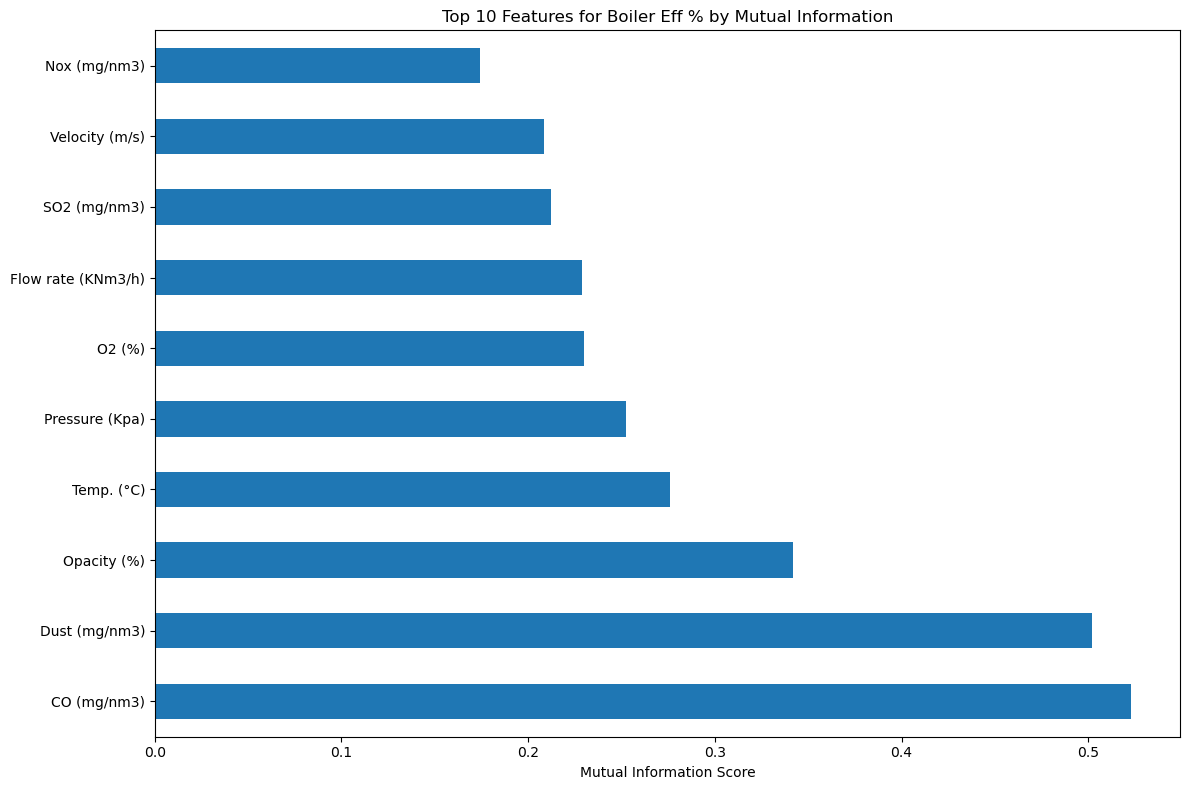

In [12]:
# Visualisasi skor MI untuk top 10 fitur
plt.figure(figsize=(12, 8))
mi_scores_boiler_df.sort_values(ascending=False).head(10).plot.barh(
    title='Top 10 Features for Boiler Eff % by Mutual Information')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()


In [13]:
!pip install Cython
!pip install pygad scikit-learn

In [14]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
import pygad

# 1. FUNGSI CUSTOM mRMR (Minimum Redundancy Maximum Relevance)
# Mencari fitur yang informatif (MI tinggi) tapi tidak mirip satu sama lain (Korelasi rendah)
def run_mrmr_selection(X_data, mi_scores, n_features=10):
    selected = []
    remaining = list(mi_scores.index)
    
    # Pilih fitur pertama dengan MI tertinggi
    first_feat = remaining.pop(0)
    selected.append(first_feat)
    
    while len(selected) < n_features and len(remaining) > 0:
        best_mrmr_score = -np.inf
        best_feat = None
        
        for feat in remaining:
            relevance = mi_scores[feat]
            # Redundancy: rata-rata korelasi absolut dengan fitur yang sudah terpilih
            redundancy = np.mean([abs(X_data[feat].corr(X_data[s])) for s in selected])
            mrmr_score = relevance - redundancy # Maximize relevance, Minimize redundancy
            
            if mrmr_score > best_mrmr_score:
                best_mrmr_score = mrmr_score
                best_feat = feat
        
        selected.append(best_feat)
        remaining.remove(best_feat)
    return selected

# 2. EKSEKUSI RFE (Recursive Feature Elimination)
print("Running RFE Selection...")
rfe_selector = RFE(estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
                   n_features_to_select=10)
rfe_selector.fit(X, y_boiler_eff)
rfe_features = X.columns[rfe_selector.support_].tolist()

# 3. EKSEKUSI mRMR
print("Running mRMR Selection...")
mrmr_features = run_mrmr_selection(X, mi_scores_boiler_df, n_features=10)

# 4. EKSEKUSI GENETIC ALGORITHM (GA)
def fitness_func(ga_instance, solution, solution_idx):
    selected_idx = [i for i, bit in enumerate(solution) if bit == 1]
    if len(selected_idx) == 0: return -9999
    
    X_subset = X.iloc[:, selected_idx]
    model = RandomForestRegressor(n_estimators=30, random_state=42)
    # Fitness berdasarkan R2 Score (Penurunan Entropy/Ketidakpastian)
    return cross_val_score(model, X_subset, y_boiler_eff, cv=3).mean()

ga_instance = pygad.GA(num_generations=20, num_parents_mating=5, 
                       fitness_func=fitness_func, sol_per_pop=10, 
                       num_genes=X.shape[1], gene_space=[0, 1])

print("Running Genetic Algorithm...")
ga_instance.run()
solution, _, _ = ga_instance.best_solution()
ga_features = [X.columns[i] for i, bit in enumerate(solution) if bit == 1]

# --- OUTPUT AKHIR ---
print("\n" + "="*50)
print("RINGKASAN FITUR TERPILIH")
print("="*50)
print(f"RFE (Model-Based) : {rfe_features}")
print(f"mRMR (Information) : {mrmr_features}")
print(f"GA (Evolutionary)  : {ga_features}")

Running RFE Selection...
Running mRMR Selection...
Running Genetic Algorithm...

RINGKASAN FITUR TERPILIH
RFE (Model-Based) : ['SO2 (mg/nm3)', 'Nox (mg/nm3)', 'CO (mg/nm3)', 'CO2 (ppm)', 'O2 (%)', 'Velocity (m/s)', 'Temp. (°C)', 'Pressure (Kpa)', 'Opacity (%)', 'Dust (mg/nm3)']
mRMR (Information) : ['CO (mg/nm3)', 'Temp. (°C)', 'Opacity (%)', 'Dust (mg/nm3)', 'Nox (mg/nm3)', 'Flow rate (KNm3/h)', 'Pressure (Kpa)', 'CO2 (ppm)', 'O2 (%)', 'Velocity (m/s)']
GA (Evolutionary)  : ['SO2 (mg/nm3)', 'Nox (mg/nm3)', 'CO2 (ppm)', 'Temp. (°C)', 'Pressure (Kpa)', 'Opacity (%)', 'Dust (mg/nm3)']


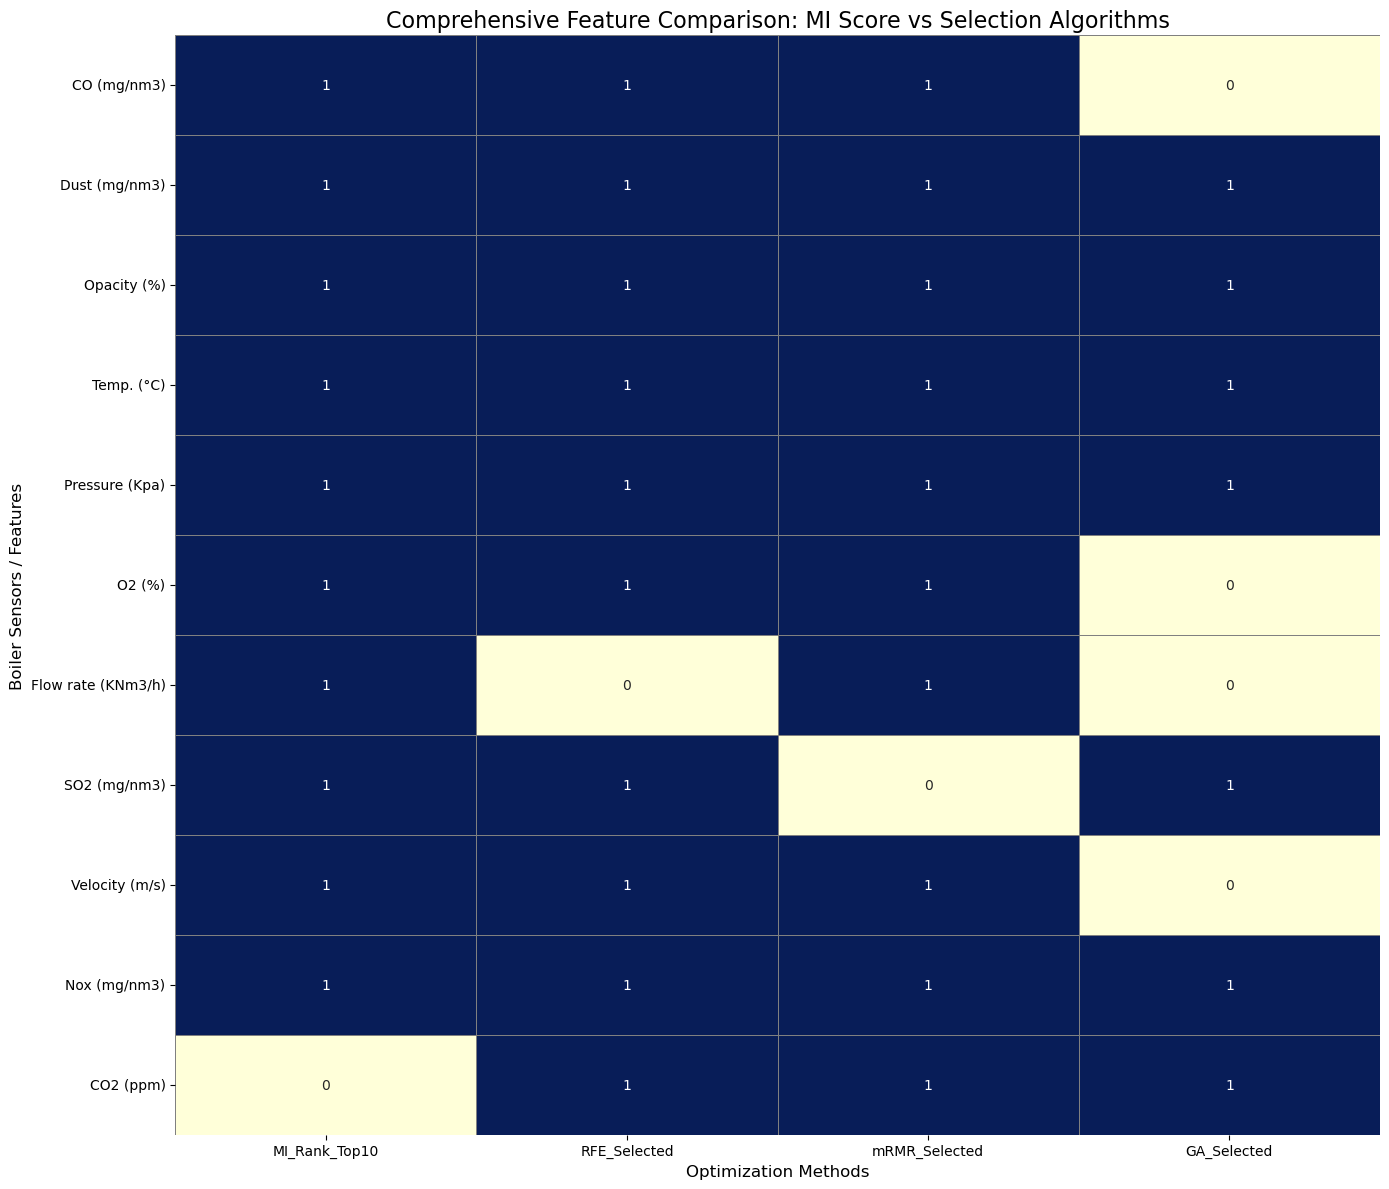


Feature Name                             | MI Score   | Top10  | RFE   | mRMR  | GA    | Total
--------------------------------------------------------------------------------------------------------------
CO (mg/nm3)                              | 0.522895   | 1      | 1     | 1     | 0     | 3
Dust (mg/nm3)                            | 0.502072   | 1      | 1     | 1     | 1     | 4
Opacity (%)                              | 0.341643   | 1      | 1     | 1     | 1     | 4
Temp. (°C)                               | 0.275956   | 1      | 1     | 1     | 1     | 4
Pressure (Kpa)                           | 0.252250   | 1      | 1     | 1     | 1     | 4
O2 (%)                                   | 0.229918   | 1      | 1     | 1     | 0     | 3
Flow rate (KNm3/h)                       | 0.228718   | 1      | 0     | 1     | 0     | 2
SO2 (mg/nm3)                             | 0.212255   | 1      | 1     | 0     | 1     | 3
Velocity (m/s)                           | 0.208672   | 1      | 

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Menyiapkan DataFrame Perbandingan untuk SELURUH Fitur
all_features = X.columns
comparison_df = pd.DataFrame(index=all_features)

# Mengisi kolom pilihan (1 jika terpilih, 0 jika tidak)
comparison_df['MI_Rank_Top10'] = [1 if f in mi_scores_boiler_df.head(10).index else 0 for f in all_features]
comparison_df['RFE_Selected'] = [1 if f in rfe_features else 0 for f in all_features]
comparison_df['mRMR_Selected'] = [1 if f in mrmr_features else 0 for f in all_features]
comparison_df['GA_Selected'] = [1 if f in ga_features else 0 for f in all_features]

# Masukkan skor MI asli sebagai kolom referensi utama
comparison_df['MI_Score'] = mi_scores_boiler_df

# Urutkan berdasarkan MI Score tertinggi agar mudah dianalisis
comparison_df = comparison_df.sort_values(by='MI_Score', ascending=False)

# 2. Visualisasi Heatmap untuk Semua Fitur
plt.figure(figsize=(14, 12))
# Kita drop kolom MI_Score hanya saat plotting agar heatmap menunjukkan nilai biner (0 atau 1)
sns.heatmap(comparison_df.drop('MI_Score', axis=1), 
            annot=True, 
            cmap='YlGnBu', 
            cbar=False, 
            linewidths=0.5,
            linecolor='gray')

plt.title('Comprehensive Feature Comparison: MI Score vs Selection Algorithms', fontsize=16)
plt.ylabel('Boiler Sensors / Features', fontsize=12)
plt.xlabel('Optimization Methods', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Tabel Perbandingan Detail (Print Output)
print("\n" + "="*110)
print(f"{'Feature Name':<40} | {'MI Score':<10} | {'Top10':<6} | {'RFE':<5} | {'mRMR':<5} | {'GA':<5} | {'Total'}")
print("-" * 110)

for feat, row in comparison_df.iterrows():
    total_votes = int(row['MI_Rank_Top10'] + row['RFE_Selected'] + row['mRMR_Selected'] + row['GA_Selected'])
    print(f"{feat:<40} | {row['MI_Score']:<10.6f} | {int(row['MI_Rank_Top10']):<6} | {int(row['RFE_Selected']):<5} | {int(row['mRMR_Selected']):<5} | {int(row['GA_Selected']):<5} | {total_votes}")

print("="*110)

# 4. Kesimpulan Fitur Paling Stabil
top_stable = comparison_df[comparison_df.drop('MI_Score', axis=1).sum(axis=1) >= 3].index.tolist()
print(f"\nGOLDEN FEATURES (Terpilih di hampir semua metode): {top_stable}")

Fitur terpilih hasil konsensus: 5 fitur


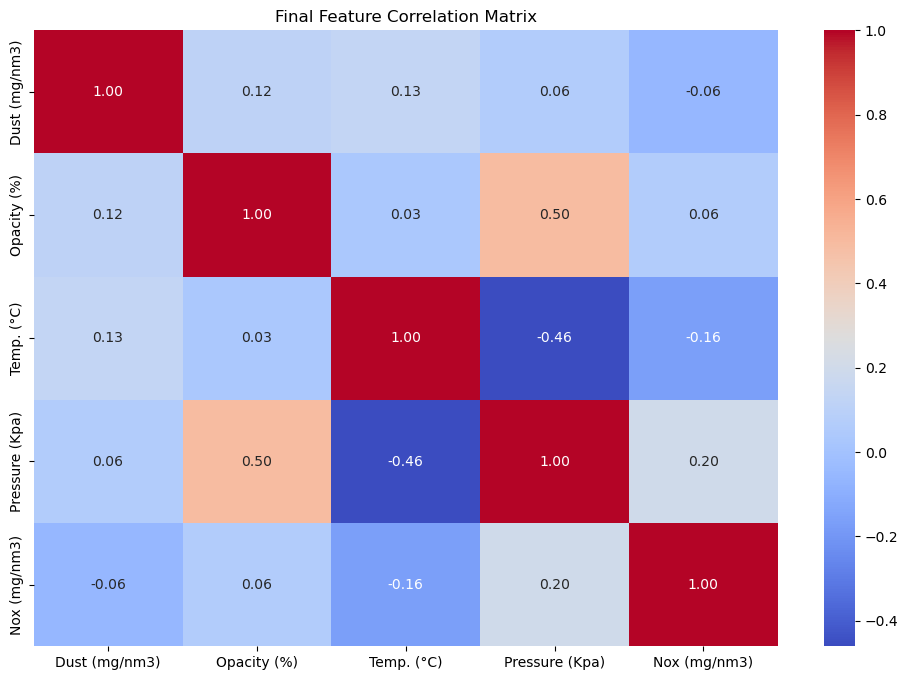


FINAL VIF ANALYSIS (Aim for VIF < 10)
          Feature         VIF
1     Opacity (%)  155.586064
2      Temp. (°C)  123.318920
3  Pressure (Kpa)   53.496407
4    Nox (mg/nm3)   37.061468
0   Dust (mg/nm3)    5.321939

✅ Dataset sudah bersih dari multikolinearitas ekstrim.


In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. OTOMATISASI EKSTRAKSI FITUR (Berdasarkan Voting)
# Kita mengambil fitur yang dipilih oleh minimal 2 metode (RFE, mRMR, atau GA)
# agar model tetap robust dan tidak overfitting.
comparison_df['Total_Votes'] = comparison_df[['MI_Rank_Top10', 'RFE_Selected', 'mRMR_Selected', 'GA_Selected']].sum(axis=1)

# Pilih fitur dengan minimal 2 suara (Opsional & Golden)
selected_mask = comparison_df['Total_Votes'] >= 4
final_feature_names = comparison_df[selected_mask].index.tolist()

print(f"Fitur terpilih hasil konsensus: {len(final_feature_names)} fitur")

# 2. DATASET PREPARATION
# Pastikan data bersih dari missing values sebelum uji VIF
X_final = X[final_feature_names].dropna()

# 3. UJI REDUNDANSI AKHIR (VIF & Correlation)
def check_multicollinearity(df):
    # Matriks Korelasi
    plt.figure(figsize=(12, 8))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Final Feature Correlation Matrix")
    plt.show()
    
    # Perhitungan VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    # Menggunakan nilai absolut karena arah korelasi tidak relevan untuk multikolinearitas
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]
    return vif_data.sort_values(by="VIF", ascending=False), corr

vif_df, corr_matrix = check_multicollinearity(X_final)

print("\n" + "="*60)
print("FINAL VIF ANALYSIS (Aim for VIF < 10)")
print("="*60)
print(vif_df)

# 4. LOGIKA PEMBERSIHAN OTOMATIS (Jika Korelasi > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("\n⚠️  REDUNDANSI TERDETEKSI:")
    for f1, f2, val in high_corr_pairs:
        # Rekomendasi: Buang yang MI Score-nya lebih rendah
        mi_f1 = comparison_df.loc[f1, 'MI_Score']
        mi_f2 = comparison_df.loc[f2, 'MI_Score']
        drop_candidate = f2 if mi_f1 > mi_f2 else f1
        print(f"- {f1} & {f2} (Corr: {val:.2f}) -> Rekomendasi buang: {drop_candidate}")
else:
    print("\n✅ Dataset sudah bersih dari multikolinearitas ekstrim.")

# 5. SIMPAN HASIL FINAL
# Dataset ini yang akan Anda gunakan untuk training model Machine Learning
final_dataset = pd.concat([X_final, y_boiler_eff], axis=1)
# final_dataset.to_csv('Boiler_Efficiency_Ready_Data.csv', index=False)

In [25]:
# 1. Pastikan initial_selection mengambil hasil dari voting (final_feature_names)
initial_selection = final_feature_names 

# 2. Karena dataset sudah bersih, kita tidak melakukan drop manual
# Kita langsung tetapkan fitur hasil voting sebagai fitur final
final_vetted_features = [f for f in initial_selection if f in X.columns]

# 3. Eksekusi Dataset Akhir
X_vetted = X[final_vetted_features].dropna()

# 4. Standard Scaling (Sangat disarankan sebelum masuk ke model)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_vetted), columns=X_vetted.columns)

print(f"Feature Selection Selesai 100%.")
print(f"Jumlah Fitur Final: {len(final_vetted_features)}")
print(f"Fitur: {final_vetted_features}")

Feature Selection Selesai 100%.
Jumlah Fitur Final: 5
Fitur: ['Dust (mg/nm3)', 'Opacity (%)', 'Temp. (°C)', 'Pressure (Kpa)', 'Nox (mg/nm3)']


In [26]:
# Cek variansi: jika nilai std (standar deviasi) sangat kecil, fitur ini bisa dibuang
print(X_vetted.std())

Dust (mg/nm3)      2.724396
Opacity (%)        0.480254
Temp. (°C)        12.049538
Pressure (Kpa)     0.045180
Nox (mg/nm3)      20.692030
dtype: float64


In [27]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi Scaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_vetted)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_vetted.columns)

# Hitung ulang VIF
vif_final = pd.DataFrame()
vif_final["Feature"] = X_scaled.columns
vif_final["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(len(X_scaled.columns))]

print(vif_final.sort_values(by="VIF", ascending=False))

          Feature       VIF
3  Pressure (Kpa)  1.951544
1     Opacity (%)  1.503591
2      Temp. (°C)  1.479926
4    Nox (mg/nm3)  1.051279
0   Dust (mg/nm3)  1.043575


VIF < 10: Secara statistik, nilai VIF di bawah 10 menunjukkan bahwa multikolinearitas sudah tidak lagi menjadi masalah yang mengganggu stabilitas model.

Data Siap Pakai: Dataset sekarang sudah sangat ramping (5 fitur terbaik) dan secara matematis stabil.

Daftar "Fitur Emas" Final 

Inilah 5 fitur yang akan digunakan untuk membangun model prediksi efisiensi boiler:

Pressure (Kpa)

Opacity (%)

Temp. (°C) 

Nox (mg/nm3)

Dust (mg/nm3)


In [47]:
# Load dataset
df = pd.read_excel('Cleaned_Dataset 2.xlsx')

# Melihat dimensi data
print(f"Dimensi data: {df.shape}")

# Melihat beberapa baris pertama data
display(df.head())

Dimensi data: (549, 13)


,SO2 (mg/nm3),Nox (mg/nm3),CO (mg/nm3),CO2 (ppm),O2 (%),Velocity (m/s),Temp. (°C),Pressure (Kpa),Flow rate (KNm3/h),Opacity (%),Dust (mg/nm3),Boiler Eff (%),NPHR (Kcal/Kwh)
0,467.109710,215.343399,675.494230,104149.435825,5.733319,13.543683,103.555908,-0.268340,521.201534,49.690183,0.269452,77.915748,2607.270106
1,487.997713,186.102138,677.919792,106112.301201,5.007743,12.093034,99.353094,-0.254642,465.376223,49.691542,0.270812,76.294873,2687.121676
2,498.073246,188.988139,679.644721,106005.810713,4.783563,11.900385,95.308560,-0.248897,457.962513,49.697809,0.272701,77.886219,2663.032090
3,503.058633,194.010835,682.033313,104089.430589,4.842330,11.613680,87.355418,-0.225933,446.929254,49.702891,0.274674,78.367624,2651.943177
4,450.895453,132.718747,478.544209,98360.057466,5.686940,12.103985,89.364968,-0.235743,465.797638,49.688853,0.283205,77.856369,2651.524408


In [48]:
# 2. Daftar fitur yang ingin dipertahankan (termasuk target NPHR)
selected_columns = [
'Pressure (Kpa)',
'Opacity (%)',
'Temp. (°C)', 
'Nox (mg/nm3)',
'Dust (mg/nm3)',
'Boiler Eff (%)'  # Menambahkan target untuk keperluan seleksi/modeling
]

# 3. Membuat dataframe baru hanya dengan fitur terpilih
# Menggunakan .copy() agar tidak terjadi SettingWithCopyWarning saat manipulasi data nanti
df_selected_boiler = df[selected_columns].copy()

# 4. Membersihkan baris yang mungkin memiliki nilai kosong (NaN) agar data siap pakai
df_selected_boiler = df_selected_boiler.dropna()

# 5. Menampilkan informasi dataframe baru
print(f"Dimensi data baru: {df_selected_boiler.shape}")
print("\nStatistik Deskriptif:")
display(df_selected_boiler.describe())

# 6. Simpan ke file Excel
file_name = '#1 final feature selected dataset 2 for boiler efficiency.xlsx'
df_selected_boiler.to_excel(file_name, index=False)
print(f"\n✅ File berhasil disimpan dengan nama: {file_name}")

Dimensi data baru: (549, 6)

Statistik Deskriptif:


,Pressure (Kpa),Opacity (%),Temp. (°C),Nox (mg/nm3),Dust (mg/nm3),Boiler Eff (%)
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,-0.288601,49.691747,113.536644,121.350162,5.513436,84.938134
std,0.045180,0.480254,12.049538,20.692030,2.724396,3.530716
min,-1.038286,41.407412,69.170952,61.237383,0.204475,76.294873
25%,-0.303721,49.702054,106.873303,106.719629,2.461368,82.548315
50%,-0.293829,49.722612,115.184237,121.350162,7.512560,84.938134
75%,-0.276941,49.739346,121.062657,133.407363,7.879734,87.192305
max,-0.106860,49.792566,141.580422,215.343399,10.798639,97.255080



✅ File berhasil disimpan dengan nama: #1 final feature selected dataset 2 for boiler efficiency.xlsx


In [28]:
# Feature Selection dengan Mutual Information untuk target 2: NPHR (Kcal/Kwh)
print("\n=== Feature Selection untuk NPHR (Kcal/Kwh) ===")


=== Feature Selection untuk NPHR (Kcal/Kwh) ===


In [29]:
# Hitung skor Mutual Information
mi_scores_nphr = mutual_info_regression(X, y_nphr, random_state=42)

In [30]:
# Buat Series untuk memudahkan analisis
mi_scores_nphr_df = pd.Series(mi_scores_nphr, index=X.columns)
mi_scores_nphr_df = mi_scores_nphr_df.sort_values(ascending=False)

In [31]:
# Tampilkan fitur skor MI
print("\nfitur untuk NPHR (Kcal/Kwh) berdasarkan Mutual Information:")
print(mi_scores_nphr_df)



fitur untuk NPHR (Kcal/Kwh) berdasarkan Mutual Information:
CO (mg/nm3)           0.449755
Dust (mg/nm3)         0.375680
O2 (%)                0.285166
Opacity (%)           0.257904
Nox (mg/nm3)          0.230610
Temp. (°C)            0.221556
Pressure (Kpa)        0.214684
Flow rate (KNm3/h)    0.208152
SO2 (mg/nm3)          0.192053
CO2 (ppm)             0.189255
Velocity (m/s)        0.188542
dtype: float64


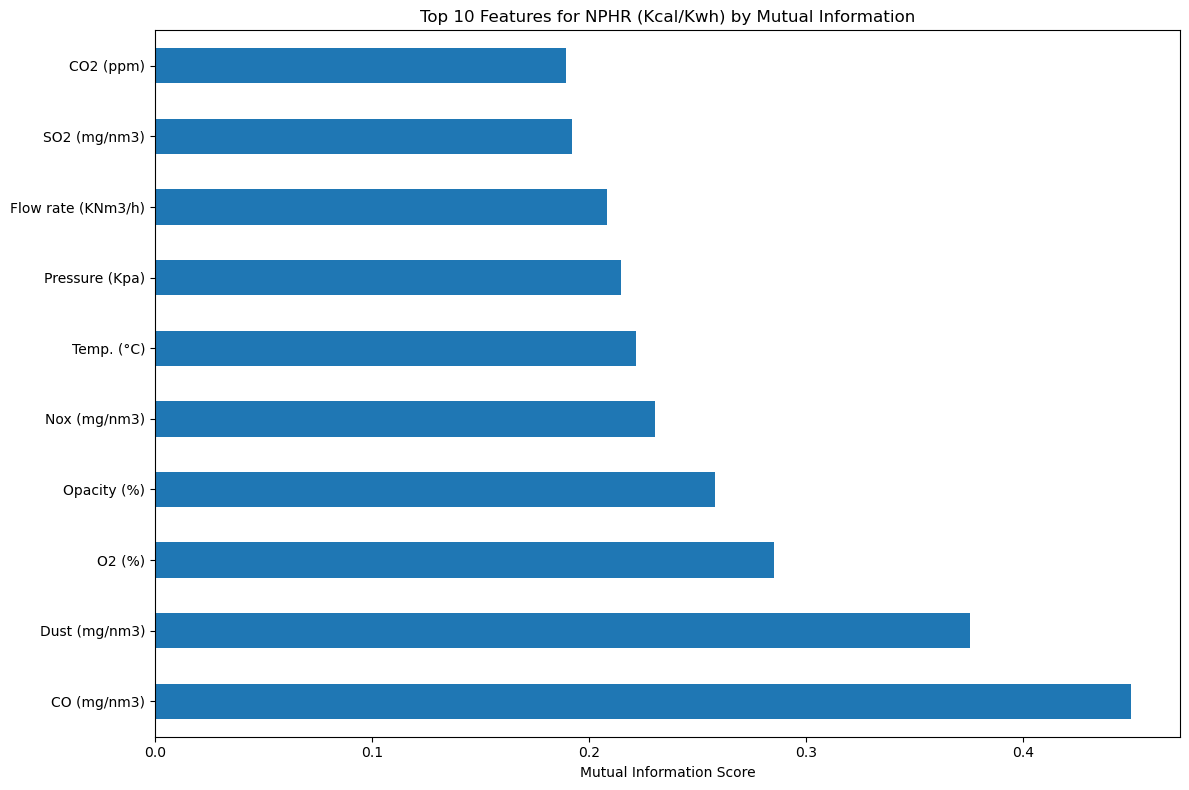

In [32]:
# Visualisasi skor MI untuk top 10 fitur
plt.figure(figsize=(12, 8))
mi_scores_nphr_df.sort_values(ascending=False).head(10).plot.barh(
    title='Top 10 Features for NPHR (Kcal/Kwh) by Mutual Information')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()


In [33]:
# PENJELASAN DETAIL PERHITUNGAN MUTUAL INFORMATION
print("\n" + "="*100)
print("PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)")
print("="*100)

print("-" * 100)
print("""
Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target
""")

print("\n🔍 ENTROPI TARGET NPHR:")
print("-" * 100)

# Hitung entropy target untuk pemahaman
from scipy.stats import entropy as scipy_entropy
import numpy as np

# Entropy dari target (mengukur seberapa "tersebar" nilai target)
target_entropy_NPHR = scipy_entropy(np.histogram(y_nphr, bins=20)[0] + 1e-10)
print(f"Target Entropy (NPHR): {target_entropy_NPHR:.6f}")
print(f"  → Ini adalah ketidakpastian maksimal sebelum mengetahui fitur apa pun")

# HITUNG THRESHOLD (Mean dari MI scores)
mi_threshold_nphr = mi_scores_nphr_df.mean()
print(f"\nThreshold MI (Mean dari 33 MI scores): {mi_threshold_nphr:.6f}")

# Hitung juga untuk NPHR (jika belum ada)
try:
    mi_threshold_nphr = mi_scores_nphr_df.mean()
except:
    mi_threshold_nphr = mi_threshold_boiler  # fallback

print("\n" + "="*100)
print("SKOR MI UNTUK SETIAP FITUR (NPHR)")
print("="*100)
print(f"{'Rank':<6} {'Fitur':<40} {'MI Score':<12} {'Kategori':<20}")
print("-" * 100)

# Urutkan dan tampilkan interpretasi
mi_sorted = mi_scores_nphr_df
for rank, (feature, score) in enumerate(mi_sorted.items(), 1):
    # Kategori pentingnya
    if score > 0.4:
        kategori = "Sangat Penting"
    elif score > 0.3:
        kategori = "Penting"
    elif score > 0.2:
        kategori = "Cukup Penting"
    else:
        kategori = "Kurang Penting"
    
    print(f"{rank:<6} {feature:<40} {score:<12.6f} {kategori:<20}")

print("-" * 100)
print(f"\nThreshold MI untuk NPHR: {mi_threshold_nphr:.6f}")
print(f"  → Fitur dengan MI > {mi_threshold_nphr:.6f} dianggap penting dan dipilih")

# Hitung jumlah fitur yang melampaui threshold
n_selected = (mi_scores_nphr_df > mi_threshold_nphr).sum()
print(f"  → {n_selected} dari {X.shape[1]} fitur melampaui threshold ini")

print("\n" + "="*100)
print("CARA KERJA ALGORITMA MI")
print("="*100)
print("""
Langkah-langkah Perhitungan MI oleh mutual_info_regression:

1. PERSIAPAN DATA
   ✓ Fitur X: 33 kolom (nilai numerik)
   ✓ Target Y: 1 kolom (Boiler Eff %)
   ✓ Sampel: 549 observasi

2. ESTIMASI DISTRIBUSI PROBABILITAS
   ✓ Algoritma membagi data menjadi bins/kurva
   ✓ Menghitung distribusi p(X) dan p(Y)
   ✓ Menghitung distribusi bersama p(X, Y)

3. PERHITUNGAN ENTROPY
   ✓ H(Y) = -Σ p(y) * log(p(y))  [entropy marginal target]
   ✓ H(Y|X) = Σ p(x) * H(Y|X=x)  [entropy kondisional]

4. KALKULASI MI
   ✓ MI = H(Y) - H(Y|X)
   ✓ Atau setara: MI = Σ Σ p(x,y) * log(p(x,y) / (p(x)*p(y)))

5. RANKING
   ✓ Urutkan fitur berdasarkan skor MI dari tertinggi ke terendah
   ✓ Ini menghasilkan ranking kepentingan fitur

Contoh Interpretasi HHV (Rank #1, MI=0.5756):
   HHV memiliki MI tertinggi (0.5756 untuk Boiler Eff)
   → Mengetahui nilai HHV mengurangi ketidakpastian tentang Boiler Eff sebesar 0.5756
   → HHV adalah fitur PALING PENTING untuk memprediksi Boiler Eff
""")

print("\n" + "="*100)


PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)
----------------------------------------------------------------------------------------------------

Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target


🔍 ENTROPI TARGET NPHR:
----------------------------------------------------------------------------------------------------
Target Entr

In [34]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
import pygad

# 1. FUNGSI CUSTOM mRMR (Minimum Redundancy Maximum Relevance)
# Mencari fitur yang informatif (MI tinggi) tapi tidak mirip satu sama lain (Korelasi rendah)
def run_mrmr_selection(X_data, mi_scores, n_features=10):
    selected = []
    remaining = list(mi_scores.index)
    
    # Pilih fitur pertama dengan MI tertinggi
    first_feat = remaining.pop(0)
    selected.append(first_feat)
    
    while len(selected) < n_features and len(remaining) > 0:
        best_mrmr_score = -np.inf
        best_feat = None
        
        for feat in remaining:
            relevance = mi_scores[feat]
            # Redundancy: rata-rata korelasi absolut dengan fitur yang sudah terpilih
            redundancy = np.mean([abs(X_data[feat].corr(X_data[s])) for s in selected])
            mrmr_score = relevance - redundancy # Maximize relevance, Minimize redundancy
            
            if mrmr_score > best_mrmr_score:
                best_mrmr_score = mrmr_score
                best_feat = feat
        
        selected.append(best_feat)
        remaining.remove(best_feat)
    return selected

# 2. EKSEKUSI RFE (Recursive Feature Elimination)
print("Running RFE Selection...")
rfe_selector = RFE(estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
                   n_features_to_select=10)
rfe_selector.fit(X, y_nphr)
rfe_features = X.columns[rfe_selector.support_].tolist()

# 3. EKSEKUSI mRMR
print("Running mRMR Selection...")
mrmr_features = run_mrmr_selection(X, mi_scores_nphr_df, n_features=10)

# 4. EKSEKUSI GENETIC ALGORITHM (GA)
def fitness_func(ga_instance, solution, solution_idx):
    selected_idx = [i for i, bit in enumerate(solution) if bit == 1]
    if len(selected_idx) == 0: return -9999
    
    X_subset = X.iloc[:, selected_idx]
    model = RandomForestRegressor(n_estimators=30, random_state=42)
    # Fitness berdasarkan R2 Score (Penurunan Entropy/Ketidakpastian)
    return cross_val_score(model, X_subset, y_nphr, cv=3).mean()

ga_instance = pygad.GA(num_generations=20, num_parents_mating=5, 
                       fitness_func=fitness_func, sol_per_pop=10, 
                       num_genes=X.shape[1], gene_space=[0, 1])

print("Running Genetic Algorithm...")
ga_instance.run()
solution, _, _ = ga_instance.best_solution()
ga_features = [X.columns[i] for i, bit in enumerate(solution) if bit == 1]

# --- OUTPUT AKHIR ---
print("\n" + "="*50)
print("RINGKASAN FITUR TERPILIH")
print("="*50)
print(f"RFE (Model-Based) : {rfe_features}")
print(f"mRMR (Information) : {mrmr_features}")
print(f"GA (Evolutionary)  : {ga_features}")

Running RFE Selection...
Running mRMR Selection...
Running Genetic Algorithm...

RINGKASAN FITUR TERPILIH
RFE (Model-Based) : ['SO2 (mg/nm3)', 'Nox (mg/nm3)', 'CO (mg/nm3)', 'CO2 (ppm)', 'O2 (%)', 'Velocity (m/s)', 'Pressure (Kpa)', 'Flow rate (KNm3/h)', 'Opacity (%)', 'Dust (mg/nm3)']
mRMR (Information) : ['CO (mg/nm3)', 'Nox (mg/nm3)', 'Opacity (%)', 'Temp. (°C)', 'Dust (mg/nm3)', 'Flow rate (KNm3/h)', 'O2 (%)', 'Pressure (Kpa)', 'CO2 (ppm)', 'Velocity (m/s)']
GA (Evolutionary)  : ['SO2 (mg/nm3)', 'Velocity (m/s)', 'Pressure (Kpa)']


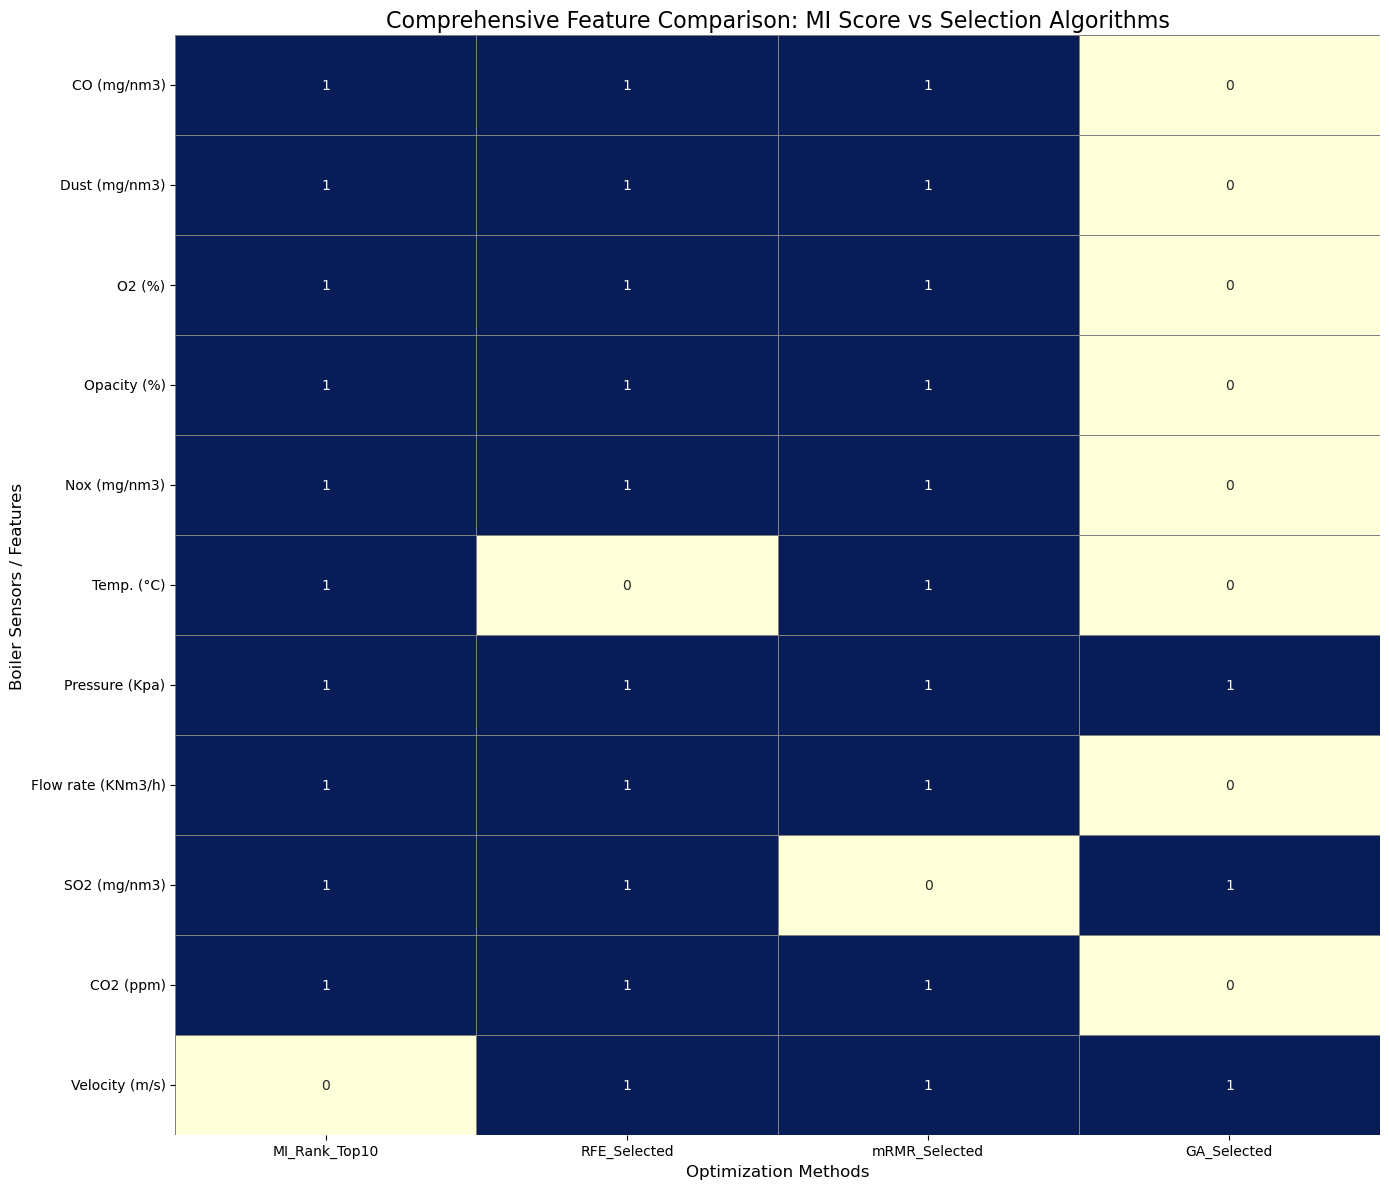


Feature Name                             | MI Score   | Top10  | RFE   | mRMR  | GA    | Total
--------------------------------------------------------------------------------------------------------------
CO (mg/nm3)                              | 0.449755   | 1      | 1     | 1     | 0     | 3
Dust (mg/nm3)                            | 0.375680   | 1      | 1     | 1     | 0     | 3
O2 (%)                                   | 0.285166   | 1      | 1     | 1     | 0     | 3
Opacity (%)                              | 0.257904   | 1      | 1     | 1     | 0     | 3
Nox (mg/nm3)                             | 0.230610   | 1      | 1     | 1     | 0     | 3
Temp. (°C)                               | 0.221556   | 1      | 0     | 1     | 0     | 2
Pressure (Kpa)                           | 0.214684   | 1      | 1     | 1     | 1     | 4
Flow rate (KNm3/h)                       | 0.208152   | 1      | 1     | 1     | 0     | 3
SO2 (mg/nm3)                             | 0.192053   | 1      | 

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Menyiapkan DataFrame Perbandingan untuk SELURUH Fitur
all_features = X.columns
comparison_df = pd.DataFrame(index=all_features)

# Mengisi kolom pilihan (1 jika terpilih, 0 jika tidak)
comparison_df['MI_Rank_Top10'] = [1 if f in mi_scores_nphr_df.head(10).index else 0 for f in all_features]
comparison_df['RFE_Selected'] = [1 if f in rfe_features else 0 for f in all_features]
comparison_df['mRMR_Selected'] = [1 if f in mrmr_features else 0 for f in all_features]
comparison_df['GA_Selected'] = [1 if f in ga_features else 0 for f in all_features]

# Masukkan skor MI asli sebagai kolom referensi utama
comparison_df['MI_Score'] = mi_scores_nphr_df

# Urutkan berdasarkan MI Score tertinggi agar mudah dianalisis
comparison_df = comparison_df.sort_values(by='MI_Score', ascending=False)

# 2. Visualisasi Heatmap untuk Semua Fitur
plt.figure(figsize=(14, 12))
# Kita drop kolom MI_Score hanya saat plotting agar heatmap menunjukkan nilai biner (0 atau 1)
sns.heatmap(comparison_df.drop('MI_Score', axis=1), 
            annot=True, 
            cmap='YlGnBu', 
            cbar=False, 
            linewidths=0.5,
            linecolor='gray')

plt.title('Comprehensive Feature Comparison: MI Score vs Selection Algorithms', fontsize=16)
plt.ylabel('Boiler Sensors / Features', fontsize=12)
plt.xlabel('Optimization Methods', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Tabel Perbandingan Detail (Print Output)
print("\n" + "="*110)
print(f"{'Feature Name':<40} | {'MI Score':<10} | {'Top10':<6} | {'RFE':<5} | {'mRMR':<5} | {'GA':<5} | {'Total'}")
print("-" * 110)

for feat, row in comparison_df.iterrows():
    total_votes = int(row['MI_Rank_Top10'] + row['RFE_Selected'] + row['mRMR_Selected'] + row['GA_Selected'])
    print(f"{feat:<40} | {row['MI_Score']:<10.6f} | {int(row['MI_Rank_Top10']):<6} | {int(row['RFE_Selected']):<5} | {int(row['mRMR_Selected']):<5} | {int(row['GA_Selected']):<5} | {total_votes}")

print("="*110)

# 4. Kesimpulan Fitur Paling Stabil
top_stable = comparison_df[comparison_df.drop('MI_Score', axis=1).sum(axis=1) >= 3].index.tolist()
print(f"\nGOLDEN FEATURES (Terpilih di hampir semua metode): {top_stable}")

Fitur terpilih hasil konsensus: 10 fitur


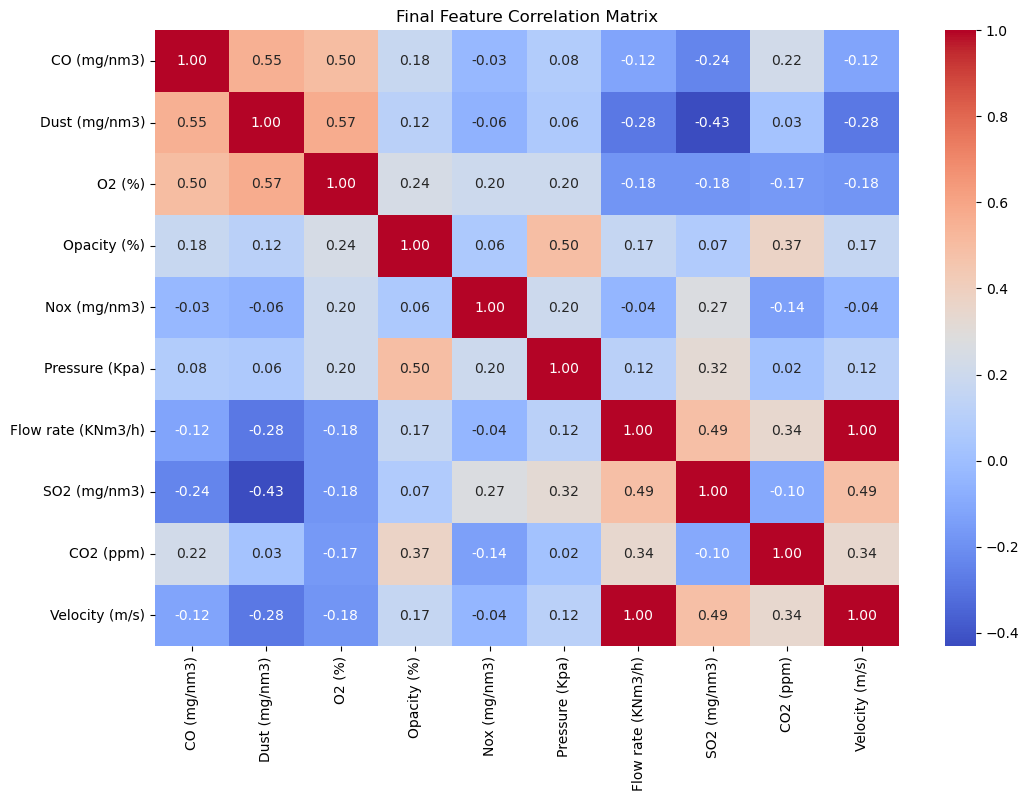


FINAL VIF ANALYSIS (Aim for VIF < 10)
              Feature          VIF
6  Flow rate (KNm3/h)          inf
9      Velocity (m/s)          inf
3         Opacity (%)  2060.790266
8           CO2 (ppm)  1918.757065
2              O2 (%)   162.599450
0         CO (mg/nm3)    90.737222
7        SO2 (mg/nm3)    62.403399
5      Pressure (Kpa)    46.060160
4        Nox (mg/nm3)    43.276870
1       Dust (mg/nm3)    10.455900

⚠️  REDUNDANSI TERDETEKSI:
- Velocity (m/s) & Flow rate (KNm3/h) (Corr: 1.00) -> Rekomendasi buang: Velocity (m/s)


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. OTOMATISASI EKSTRAKSI FITUR (Berdasarkan Voting)
# Kita mengambil fitur yang dipilih oleh minimal 2 metode (RFE, mRMR, atau GA)
# agar model tetap robust dan tidak overfitting.
comparison_df['Total_Votes'] = comparison_df[['MI_Rank_Top10', 'RFE_Selected', 'mRMR_Selected', 'GA_Selected']].sum(axis=1)

# Pilih fitur dengan minimal 2 suara (Opsional & Golden)
selected_mask = comparison_df['Total_Votes'] >= 3
final_feature_names = comparison_df[selected_mask].index.tolist()

print(f"Fitur terpilih hasil konsensus: {len(final_feature_names)} fitur")

# 2. DATASET PREPARATION
# Pastikan data bersih dari missing values sebelum uji VIF
X_final = X[final_feature_names].dropna()

# 3. UJI REDUNDANSI AKHIR (VIF & Correlation)
def check_multicollinearity(df):
    # Matriks Korelasi
    plt.figure(figsize=(12, 8))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Final Feature Correlation Matrix")
    plt.show()
    
    # Perhitungan VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    # Menggunakan nilai absolut karena arah korelasi tidak relevan untuk multikolinearitas
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]
    return vif_data.sort_values(by="VIF", ascending=False), corr

vif_df, corr_matrix = check_multicollinearity(X_final)

print("\n" + "="*60)
print("FINAL VIF ANALYSIS (Aim for VIF < 10)")
print("="*60)
print(vif_df)

# 4. LOGIKA PEMBERSIHAN OTOMATIS (Jika Korelasi > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("\n⚠️  REDUNDANSI TERDETEKSI:")
    for f1, f2, val in high_corr_pairs:
        # Rekomendasi: Buang yang MI Score-nya lebih rendah
        mi_f1 = comparison_df.loc[f1, 'MI_Score']
        mi_f2 = comparison_df.loc[f2, 'MI_Score']
        drop_candidate = f2 if mi_f1 > mi_f2 else f1
        print(f"- {f1} & {f2} (Corr: {val:.2f}) -> Rekomendasi buang: {drop_candidate}")
else:
    print("\n✅ Dataset sudah bersih dari multikolinearitas ekstrim.")

# 5. SIMPAN HASIL FINAL
# Dataset ini yang akan Anda gunakan untuk training model Machine Learning
final_dataset = pd.concat([X_final, y_nphr], axis=1)
# final_dataset.to_csv('nphr_Ready_Data.csv', index=False)

In [41]:
# Cek variansi: jika nilai std (standar deviasi) sangat kecil, fitur ini bisa dibuang
print(X_vetted.std())

CO (mg/nm3)            109.243272
Dust (mg/nm3)            2.724396
O2 (%)                   0.617149
Opacity (%)              0.480254
Nox (mg/nm3)            20.692030
Pressure (Kpa)           0.045180
Flow rate (KNm3/h)      39.091200
SO2 (mg/nm3)            79.613273
CO2 (ppm)             3208.108939
dtype: float64


Fitur terpilih hasil konsensus: 9 fitur


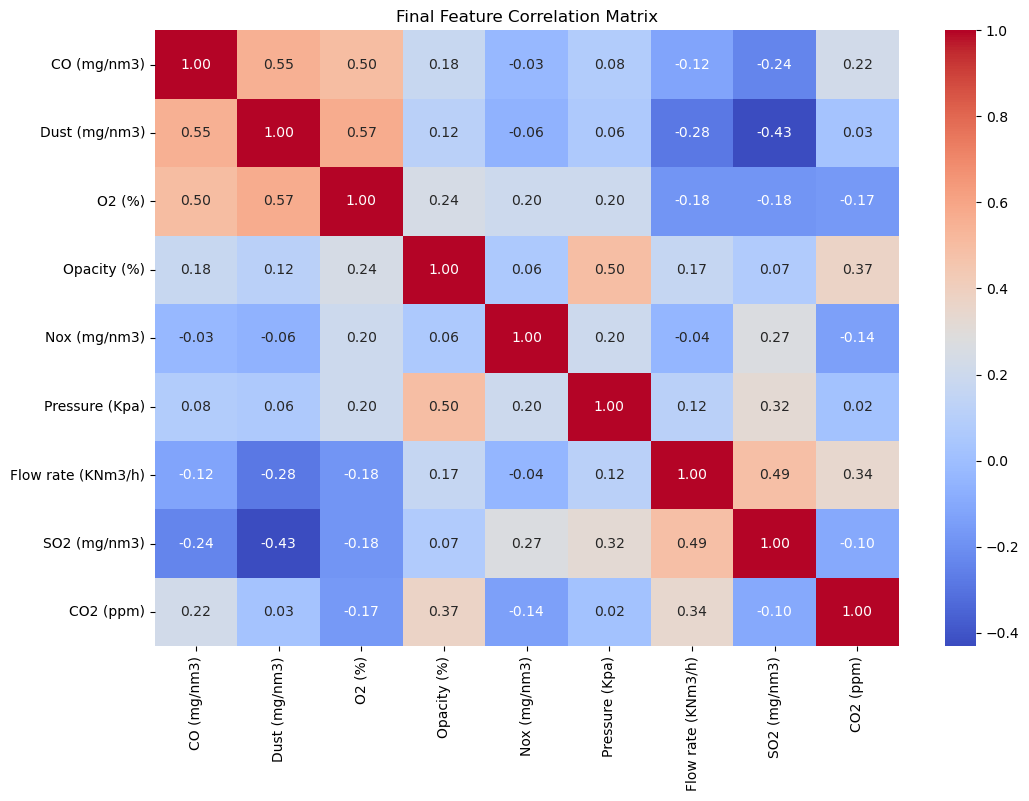


FINAL VIF ANALYSIS (Aim for VIF < 10)
              Feature          VIF
3         Opacity (%)  2060.790266
8           CO2 (ppm)  1918.757065
6  Flow rate (KNm3/h)   271.013319
2              O2 (%)   162.599450
0         CO (mg/nm3)    90.737222
7        SO2 (mg/nm3)    62.403399
5      Pressure (Kpa)    46.060160
4        Nox (mg/nm3)    43.276870
1       Dust (mg/nm3)    10.455900

✅ Dataset sudah bersih dari multikolinearitas ekstrim.


In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. OTOMATISASI EKSTRAKSI FITUR (Berdasarkan Voting)
# Kita mengambil fitur yang dipilih oleh minimal 2 metode (RFE, mRMR, atau GA)
# agar model tetap robust dan tidak overfitting.
comparison_df['Total_Votes'] = comparison_df[['MI_Rank_Top10', 'RFE_Selected', 'mRMR_Selected', 'GA_Selected']].sum(axis=1)

# Pilih fitur dengan minimal 2 suara (Opsional & Golden)
selected_mask = comparison_df['Total_Votes'] >= 3
# final_feature_names = comparison_df[selected_mask].index.tolist()

print(f"Fitur terpilih hasil konsensus: {len(final_vetted_features)} fitur")

# 2. DATASET PREPARATION
# Pastikan data bersih dari missing values sebelum uji VIF
X_final = X[final_vetted_features].dropna()

# 3. UJI REDUNDANSI AKHIR (VIF & Correlation)
def check_multicollinearity(df):
    # Matriks Korelasi
    plt.figure(figsize=(12, 8))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Final Feature Correlation Matrix")
    plt.show()
    
    # Perhitungan VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    # Menggunakan nilai absolut karena arah korelasi tidak relevan untuk multikolinearitas
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]
    return vif_data.sort_values(by="VIF", ascending=False), corr

vif_df, corr_matrix = check_multicollinearity(X_final)

print("\n" + "="*60)
print("FINAL VIF ANALYSIS (Aim for VIF < 10)")
print("="*60)
print(vif_df)

# 4. LOGIKA PEMBERSIHAN OTOMATIS (Jika Korelasi > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("\n⚠️  REDUNDANSI TERDETEKSI:")
    for f1, f2, val in high_corr_pairs:
        # Rekomendasi: Buang yang MI Score-nya lebih rendah
        mi_f1 = comparison_df.loc[f1, 'MI_Score']
        mi_f2 = comparison_df.loc[f2, 'MI_Score']
        drop_candidate = f2 if mi_f1 > mi_f2 else f1
        print(f"- {f1} & {f2} (Corr: {val:.2f}) -> Rekomendasi buang: {drop_candidate}")
else:
    print("\n✅ Dataset sudah bersih dari multikolinearitas ekstrim.")

# 5. SIMPAN HASIL FINAL
# Dataset ini yang akan Anda gunakan untuk training model Machine Learning
final_dataset = pd.concat([X_final, y_nphr], axis=1)
# final_dataset.to_csv('nphr_Ready_Data.csv', index=False)

In [46]:
# Cek variansi: jika nilai std (standar deviasi) sangat kecil, fitur ini bisa dibuang
print(X_final.std())

CO (mg/nm3)            109.243272
Dust (mg/nm3)            2.724396
O2 (%)                   0.617149
Opacity (%)              0.480254
Nox (mg/nm3)            20.692030
Pressure (Kpa)           0.045180
Flow rate (KNm3/h)      39.091200
SO2 (mg/nm3)            79.613273
CO2 (ppm)             3208.108939
dtype: float64


In [44]:
# 1. Daftar fitur yang ingin Anda BUANG (Blacklist) berdasarkan hasil VIF sebelumnya
features_to_drop = [
    'Velocity (m/s)'
]

# 2. Ambil fitur awal dari hasil voting (Gunakan nama variabel yang benar: final_feature_names)
# Variabel ini berasal dari blok "OTOMATISASI EKSTRAKSI FITUR" Anda sebelumnya
initial_selection = final_feature_names 

# 3. Filter fitur: Ambil yang ada di initial_selection TAPI tidak ada di features_to_drop
final_vetted_features = [f for f in initial_selection if f not in features_to_drop]

# 4. Pastikan fitur benar-benar ada di DataFrame X
final_vetted_features = [f for f in final_vetted_features if f in X.columns]

# 5. Eksekusi Uji VIF dan Scaling untuk hasil akhir yang stabil
X_vetted = X[final_vetted_features].dropna()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_vetted), columns=X_vetted.columns)

print(f"Fitur yang dibuang: {features_to_drop}")
print(f"Fitur yang tersisa ({len(final_vetted_features)}): {final_vetted_features}\n")

# Hitung VIF pada data yang sudah di-scale
vif_final = pd.DataFrame()
vif_final["Feature"] = X_scaled.columns
vif_final["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(len(X_scaled.columns))]

print("="*50)
print("HASIL VIF FINAL (Dataset Stabil)")
print("="*50)
print(vif_final.sort_values(by="VIF", ascending=False))

Fitur yang dibuang: ['Velocity (m/s)']
Fitur yang tersisa (9): ['CO (mg/nm3)', 'Dust (mg/nm3)', 'O2 (%)', 'Opacity (%)', 'Nox (mg/nm3)', 'Pressure (Kpa)', 'Flow rate (KNm3/h)', 'SO2 (mg/nm3)', 'CO2 (ppm)']

HASIL VIF FINAL (Dataset Stabil)
              Feature       VIF
2              O2 (%)  2.137728
7        SO2 (mg/nm3)  2.068215
1       Dust (mg/nm3)  2.054021
8           CO2 (ppm)  1.837200
0         CO (mg/nm3)  1.770454
3         Opacity (%)  1.767469
6  Flow rate (KNm3/h)  1.748254
5      Pressure (Kpa)  1.595067
4        Nox (mg/nm3)  1.225991


VIF < 10: Secara statistik, nilai VIF di bawah 9 menunjukkan bahwa multikolinearitas sudah tidak lagi menjadi masalah yang mengganggu stabilitas model.

Data Siap Pakai: Dataset sekarang sudah sangat ramping (9 fitur terbaik) dan secara matematis stabil.

Daftar "Fitur Emas" Final 

Inilah 9 fitur yang akan digunakan untuk membangun model prediksi nphr:

O2 (%)

SO2 (mg/nm3)

Dust (mg/nm3)

CO2 (ppm)

CO (mg/nm3)

Opacity (%)

Flow rate (KNm3/h)

Pressure (Kpa)

Nox (mg/nm3)

In [49]:
# Load dataset
df = pd.read_excel('Cleaned_Dataset 2.xlsx')

# Melihat dimensi data
print(f"Dimensi data: {df.shape}")

# Melihat beberapa baris pertama data
display(df.head())

Dimensi data: (549, 13)


,SO2 (mg/nm3),Nox (mg/nm3),CO (mg/nm3),CO2 (ppm),O2 (%),Velocity (m/s),Temp. (°C),Pressure (Kpa),Flow rate (KNm3/h),Opacity (%),Dust (mg/nm3),Boiler Eff (%),NPHR (Kcal/Kwh)
0,467.109710,215.343399,675.494230,104149.435825,5.733319,13.543683,103.555908,-0.268340,521.201534,49.690183,0.269452,77.915748,2607.270106
1,487.997713,186.102138,677.919792,106112.301201,5.007743,12.093034,99.353094,-0.254642,465.376223,49.691542,0.270812,76.294873,2687.121676
2,498.073246,188.988139,679.644721,106005.810713,4.783563,11.900385,95.308560,-0.248897,457.962513,49.697809,0.272701,77.886219,2663.032090
3,503.058633,194.010835,682.033313,104089.430589,4.842330,11.613680,87.355418,-0.225933,446.929254,49.702891,0.274674,78.367624,2651.943177
4,450.895453,132.718747,478.544209,98360.057466,5.686940,12.103985,89.364968,-0.235743,465.797638,49.688853,0.283205,77.856369,2651.524408


In [51]:
# 2. Daftar fitur yang ingin dipertahankan (termasuk target NPHR)
selected_columns = [
    'O2 (%)',
    'SO2 (mg/nm3)',
    'Dust (mg/nm3)',
    'CO2 (ppm)',
    'CO (mg/nm3)',
    'Opacity (%)',
    'Flow rate (KNm3/h)',
    'Pressure (Kpa)',
    'Nox (mg/nm3)',
    'NPHR (Kcal/Kwh)'  # Menambahkan target untuk keperluan seleksi/modeling
]

# 3. Membuat dataframe baru hanya dengan fitur terpilih
# Menggunakan .copy() agar tidak terjadi SettingWithCopyWarning saat manipulasi data nanti
df_selected_nphr = df[selected_columns].copy()

# 4. Membersihkan baris yang mungkin memiliki nilai kosong (NaN) agar data siap pakai
df_selected_nphr = df_selected_nphr.dropna()

# 5. Menampilkan informasi dataframe baru
print(f"Dimensi data baru: {df_selected_nphr.shape}")
print("\nStatistik Deskriptif:")
display(df_selected_nphr.describe())

# 6. Simpan ke file Excel
file_name = '#1 final feature selected dataset 2 for nphr.xlsx'
df_selected_nphr.to_excel(file_name, index=False)

print(f"\n✅ File berhasil disimpan dengan nama: {file_name}")

Dimensi data baru: (549, 10)

Statistik Deskriptif:


,O2 (%),SO2 (mg/nm3),Dust (mg/nm3),CO2 (ppm),CO (mg/nm3),Opacity (%),Flow rate (KNm3/h),Pressure (Kpa),Nox (mg/nm3),NPHR (Kcal/Kwh)
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,5.380965,432.598611,5.513436,104594.961021,773.775742,49.691747,485.041257,-0.288601,121.350162,2505.527823
std,0.617149,79.613273,2.724396,3208.108939,109.243272,0.480254,39.091200,0.045180,20.692030,93.809060
min,3.194799,202.769128,0.204475,70509.647274,338.437718,41.407412,247.675349,-1.038286,61.237383,2191.472033
25%,5.129465,386.400365,2.461368,103214.808617,742.686594,49.702054,467.491975,-0.303721,106.719629,2455.553521
50%,5.413480,453.231619,7.512560,104594.961021,809.258996,49.722612,485.041257,-0.293829,121.350162,2508.676793
75%,5.840079,496.124840,7.879734,106145.260189,841.117994,49.739346,504.072503,-0.276941,133.407363,2568.594923
max,7.212713,568.768529,10.798639,113768.549839,944.769940,49.792566,639.597720,-0.106860,215.343399,2752.407005



✅ File berhasil disimpan dengan nama: #1 final feature selected dataset 2 for nphr.xlsx
